<h1>Radar de Risco Macroeconômico — Análise Exploratória de Dados (EDA)</h1>

análise exploratória e estatística dos indicadores macroeconômicos e de risco de crédito obtidos a partir das bases de dados do Banco Central do Brasil (BCB/SGS) e do IBGE.
 O foco principal é avaliar a sensibilidade da inadimplência frente aos ciclos de política monetária (Selic) e inflação (IPCA).

<h2>Importação de Bibliotecas</h2>

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


<h2>Carga da Base de Dados Tratada</h2>

In [ ]:
# Lendo dados
df_final = pd.read_csv('../dados/tratados/dados_tratados.csv', sep=',')

df_final

,data,IPCA,Spread_do_Crédito,Taxa_de_Inadimplência,Taxa_de_juros,Taxa_Selic,Taxa_Desemprego,juro_real,pressao_financeira,Spread_Selic,inadimplência_zscore
0,01/2020,0.21,18.45,3.00,4.40,4.50,11.3,4.29,2.84,4.10,-0.13
1,02/2020,0.25,18.65,3.04,4.19,4.29,11.7,4.04,3.26,4.34,-0.06
2,03/2020,0.07,18.06,3.18,3.95,4.04,12.4,3.97,0.90,4.47,0.18
3,04/2020,-0.31,17.08,3.29,3.65,3.75,12.7,4.06,-3.82,4.55,0.36
4,05/2020,-0.38,16.53,3.24,3.01,3.15,13.1,3.53,-3.87,5.26,0.28
...,...,...,...,...,...,...,...,...,...,...,...
72,01/2026,0.33,21.76,4.26,14.90,15.00,5.4,14.67,21.09,1.45,1.99
73,02/2026,0.70,22.11,4.44,14.90,15.00,5.8,14.30,46.62,1.47,2.30
74,03/2026,0.88,21.92,4.33,14.80,14.90,6.1,14.02,56.76,1.47,2.11
75,04/2026,0.67,22.60,4.44,14.64,14.74,5.8,14.07,43.85,1.53,2.30


<h2>verificando a estrutura do DataFrame</h2>

In [2]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   data                   77 non-null     object 
 1   IPCA                   76 non-null     float64
 2   Spread_do_Crédito      76 non-null     float64
 3   Taxa_de_Inadimplência  76 non-null     float64
 4   Taxa_de_juros          77 non-null     float64
 5   Taxa_Selic             77 non-null     float64
 6   Taxa_Desemprego        76 non-null     float64
 7   juro_real              76 non-null     float64
 8   pressao_financeira     76 non-null     float64
 9   Spread_Selic           76 non-null     float64
 10  inadimplência_zscore   76 non-null     float64
dtypes: float64(10), object(1)
memory usage: 6.7+ KB


<h2>extrair as medidas de tendência central e dispersão (média, mediana, desvio padrão, mínimos e máximos) de cada indicador econômico</h2>


In [3]:
df_final.describe()

,IPCA,Spread_do_Crédito,Taxa_de_Inadimplência,Taxa_de_juros,Taxa_Selic,Taxa_Desemprego,juro_real,pressao_financeira,Spread_Selic,inadimplência_zscore
count,76.000000,76.000000,76.000000,77.000000,77.000000,76.000000,76.000000,76.000000,76.000000,76.000000
mean,0.470526,18.240263,3.075526,9.994545,10.095455,9.367105,9.566974,13.778553,2.635526,0.000526
std,0.418326,2.405571,0.594399,4.650440,4.649461,3.176387,4.748454,14.808614,1.976344,1.000072
min,-0.680000,14.130000,2.110000,1.900000,2.000000,5.100000,0.650000,-24.960000,1.350000,-1.620000
25%,0.240000,16.082500,2.635000,5.010000,5.120000,6.750000,4.280000,4.022500,1.450000,-0.745000
50%,0.435000,18.555000,3.170000,11.650000,11.750000,8.300000,11.120000,12.445000,1.600000,0.160000
75%,0.715000,20.217500,3.442500,13.650000,13.750000,12.175000,13.385000,21.142500,2.952500,0.615000
max,1.620000,22.600000,4.440000,14.900000,15.000000,14.900000,15.110000,56.760000,7.790000,2.300000


<h2>verificar dados nulos e se te tiver vou removelos</h2>


In [4]:
df_final.isna().sum()

data                     0
IPCA                     1
Spread_do_Crédito        1
Taxa_de_Inadimplência    1
Taxa_de_juros            0
Taxa_Selic               0
Taxa_Desemprego          1
juro_real                1
pressao_financeira       1
Spread_Selic             1
inadimplência_zscore     1
dtype: int64

In [5]:
df_final.dropna()

,data,IPCA,Spread_do_Crédito,Taxa_de_Inadimplência,Taxa_de_juros,Taxa_Selic,Taxa_Desemprego,juro_real,pressao_financeira,Spread_Selic,inadimplência_zscore
0,01/2020,0.21,18.45,3.00,4.40,4.50,11.3,4.29,2.84,4.10,-0.13
1,02/2020,0.25,18.65,3.04,4.19,4.29,11.7,4.04,3.26,4.34,-0.06
2,03/2020,0.07,18.06,3.18,3.95,4.04,12.4,3.97,0.90,4.47,0.18
3,04/2020,-0.31,17.08,3.29,3.65,3.75,12.7,4.06,-3.82,4.55,0.36
4,05/2020,-0.38,16.53,3.24,3.01,3.15,13.1,3.53,-3.87,5.26,0.28
...,...,...,...,...,...,...,...,...,...,...,...
71,12/2025,0.33,21.11,4.02,14.90,15.00,5.1,14.67,19.90,1.41,1.59
72,01/2026,0.33,21.76,4.26,14.90,15.00,5.4,14.67,21.09,1.45,1.99
73,02/2026,0.70,22.11,4.44,14.90,15.00,5.8,14.30,46.62,1.47,2.30
74,03/2026,0.88,21.92,4.33,14.80,14.90,6.1,14.02,56.76,1.47,2.11


<h2>Matriz de correlação entre as colunas do DF</h2>

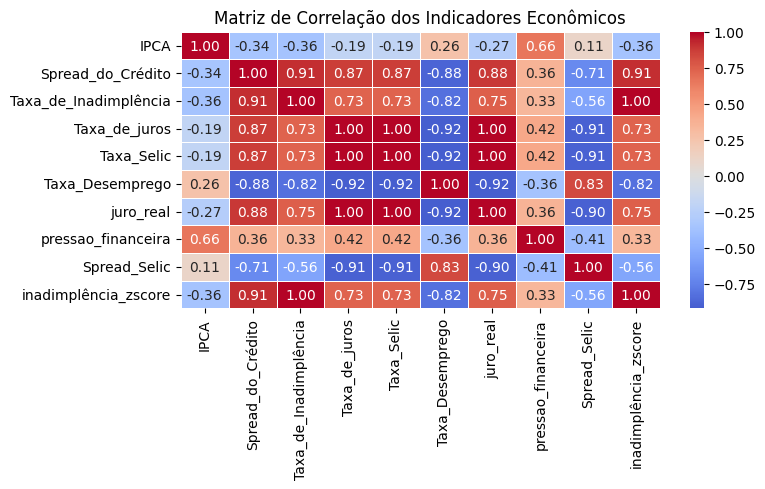

In [ ]:
# Matriz de correlação
corr = df_final.corr(numeric_only=True)

plt.figure(figsize=(8, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de Correlação dos Indicadores Econômicos")
plt.tight_layout()
plt.show()

<h2>Rank de correlação com taxa de Inadimplência</h2>

In [16]:
corr = (
    df_final
    .corr(numeric_only=True)
    ['Taxa_de_Inadimplência']
    .sort_values(ascending=False)
)

print(corr)

Taxa_de_Inadimplência    1.000000
inadimplência_zscore     0.999996
Spread_do_Crédito        0.914250
juro_real                0.747182
Taxa_de_juros            0.730157
Taxa_Selic               0.729979
pressao_financeira       0.334246
IPCA                    -0.363110
Spread_Selic            -0.560965
Taxa_Desemprego         -0.824058
Name: Taxa_de_Inadimplência, dtype: float64


<h2>correlação emtre taxa de Inadimplência e Taxa Desemprego</h2>

aqui vemos a comprovação do que vemos na matriz que a correlação entre desemprego e inadimplencia é negativa isso sujero que talvez desemprego não seja um fator tão forte 
para Inadimplência como selic

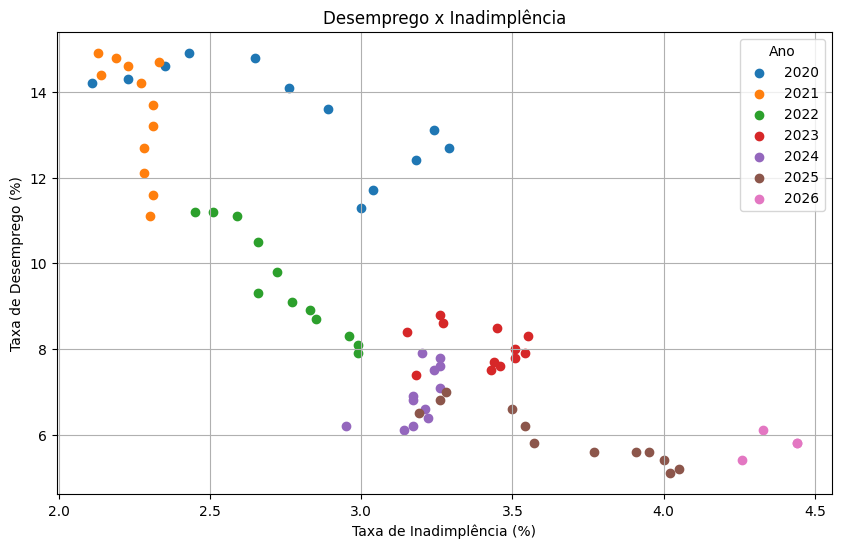

In [ ]:
# Extrai o ano
df_final['ano'] = df_final['data'].str[-4:]

plt.figure(figsize=(10,6))

for ano, grupo in df_final.groupby('ano'):

    plt.scatter(
        grupo['Taxa_de_Inadimplência'],
        grupo['Taxa_Desemprego'],
        label=ano
    )

    # Escreve o mês/ano ao lado de cada ponto
    for _, row in grupo.iterrows():

        plt.annotate(
            '',
            (
                row['Taxa_de_Inadimplência'],
                row['Taxa_Desemprego']
            ),
            fontsize=8
        )

plt.xlabel('Taxa de Inadimplência (%)')
plt.ylabel('Taxa de Desemprego (%)')
plt.title('Desemprego x Inadimplência')
plt.legend(title='Ano')
plt.grid(True)

plt.show()

<h2>Analise de lag Defasagem, quanto tempo demora para taxa de inadimplecia sofrer alteração a partir de uma mudança na Selic</h2>

vemos que nosso pico fica em 6 meses

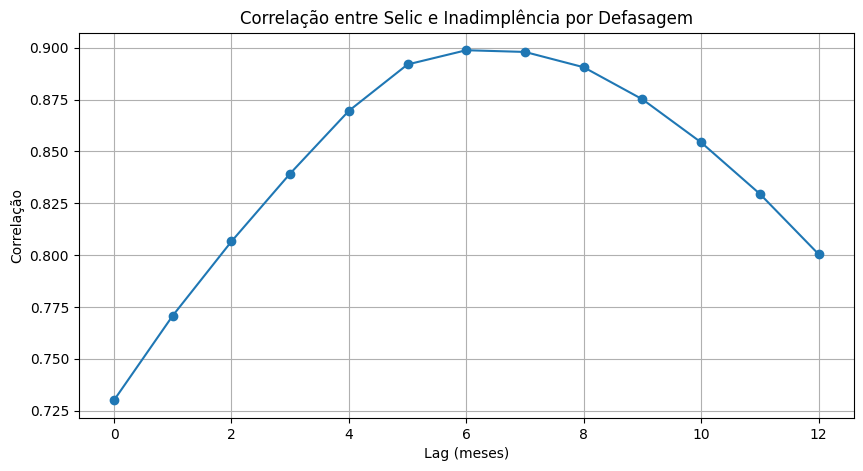

In [17]:
lags = []
correlacoes = []

for lag in range(0, 13):

    corr = (
        df_final['Taxa_Selic']
        .shift(lag)
        .corr(df_final['Taxa_de_Inadimplência'])
    )

    lags.append(lag)
    correlacoes.append(corr)

plt.figure(figsize=(10,5))

plt.plot(
    lags,
    correlacoes,
    marker='o'
)

plt.xlabel('Lag (meses)')
plt.ylabel('Correlação')
plt.title('Correlação entre Selic e Inadimplência por Defasagem')

plt.grid(True)

plt.show()

<h2>Correlação entre Selic e Inadimplência</h2>

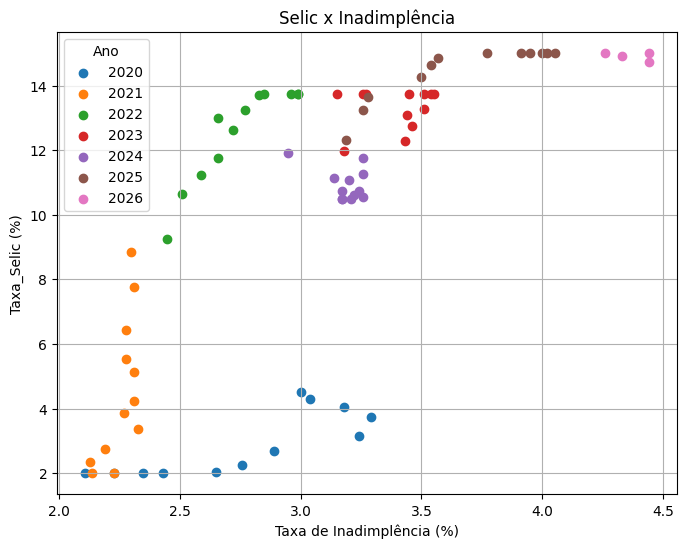

In [15]:
import matplotlib.pyplot as plt

# Extrai o ano
df_final['ano'] = df_final['data'].str[-4:]

plt.figure(figsize=(8,6))

for ano, grupo in df_final.groupby('ano'):

    plt.scatter(
        grupo['Taxa_de_Inadimplência'],
        grupo['Taxa_Selic'],
        label=ano
    )

    # Escreve o mês/ano ao lado de cada ponto
    for _, row in grupo.iterrows():

        plt.annotate(
            '',
            (
                row['Taxa_de_Inadimplência'],
                row['Taxa_Selic']
            ),
            fontsize=8
        )

plt.xlabel('Taxa de Inadimplência (%)')
plt.ylabel('Taxa_Selic (%)')
plt.title('Selic x Inadimplência')
plt.legend(title='Ano')
plt.grid(True)

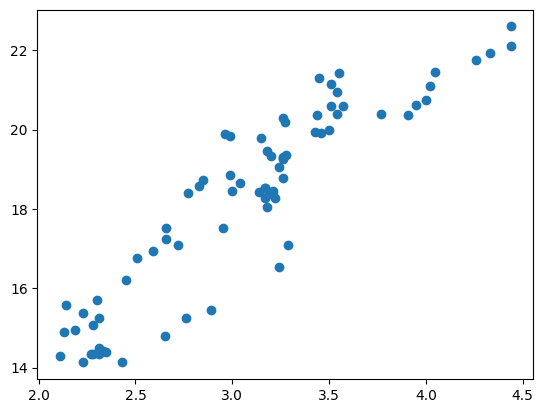

In [18]:
plt.scatter(
    df_final['Taxa_de_Inadimplência'],
    df_final['Spread_do_Crédito']
)